In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Trimestralização dos Dados

In [ ]:
df = pd.read_excel('consumo_01_03_proj.xlsx', parse_dates=[0])
df.rename(columns={df.columns[0]: 'data'}, inplace=True)
df.head()

,data,Consumo_das_familias,renda_real,IPCA,juro_medio_credito_pf,Concessao_credit_fam,despesa_gov
0,2013-03-31,174.38,117.588766,121.080067,102.053333,100.245178,141.99
1,2013-06-30,178.01,117.823885,122.778111,102.020000,103.203116,149.21
2,2013-09-30,181.96,123.942617,123.519873,102.063333,106.997914,150.24
3,2013-12-31,187.56,126.037851,125.445582,102.113333,109.089408,155.21
4,2014-03-31,180.61,124.861605,128.110954,102.210000,110.498244,144.88


In [ ]:
# Essa linha converte a coluna de datas para datetime (isso já foi feito, porém como o colab apontou erro, refiz)
df['data'] = pd.to_datetime(df['data'])

#  Data como índice
df.set_index('data', inplace=True)

In [ ]:
" O número índice está mensalizado, a ideia é trasformá-lo em trimestral"
df_trimestral = df.resample('QE').mean()
df_trimestral['renda_real'] = df['renda_real'].resample('QE').mean()
df_trimestral['IPCA'] = df['IPCA'].resample('QE').mean()
df_trimestral['juro_medio_credito_pf'] = df['juro_medio_credito_pf'].resample('QE').mean()
df_trimestral['Conceçao_credit_fam'] = df['Conceçao_credit_fam'].resample('QE').mean()
df_trimestral.head()

,renda_real,IPCA,juro_medio_credito_pf,Conceçao_credit_fam
data,,,,
2013-03-31,117.588766,121.080067,102.053333,100.245178
2013-06-30,117.823885,122.778111,102.020000,103.203116
2013-09-30,123.942617,123.519873,102.063333,106.997914
2013-12-31,126.037851,125.445582,102.113333,109.089408
2014-03-31,124.861605,128.110954,102.210000,110.498244


In [ ]:
df_trimestral = df_trimestral.to_excel('dados_trimestralizados.xlsx')

# Estruturação da Projeção

In [ ]:
df = pd.read_excel('consumo_01_03_proj.xlsx', parse_dates=[0])
df.rename(columns={df.columns[0]: 'data'}, inplace=True)
df.tail()

,data,Consumo_das_familias,renda_real,IPCA,juro_medio_credito_pf,Concessao_credit_fam,despesa_gov
42,2023-09-30,197.26,149.922953,221.499939,102.560000,166.077042,159.96
43,2023-12-31,203.08,149.813497,223.418467,102.456667,170.226972,163.47
44,2024-03-31,195.80,151.831901,226.770701,102.370000,172.525299,153.45
45,2024-06-30,199.73,151.677880,229.363057,102.373333,174.766943,160.48
46,2024-09-30,208.18,156.989539,231.216965,102.360000,178.821736,161.98


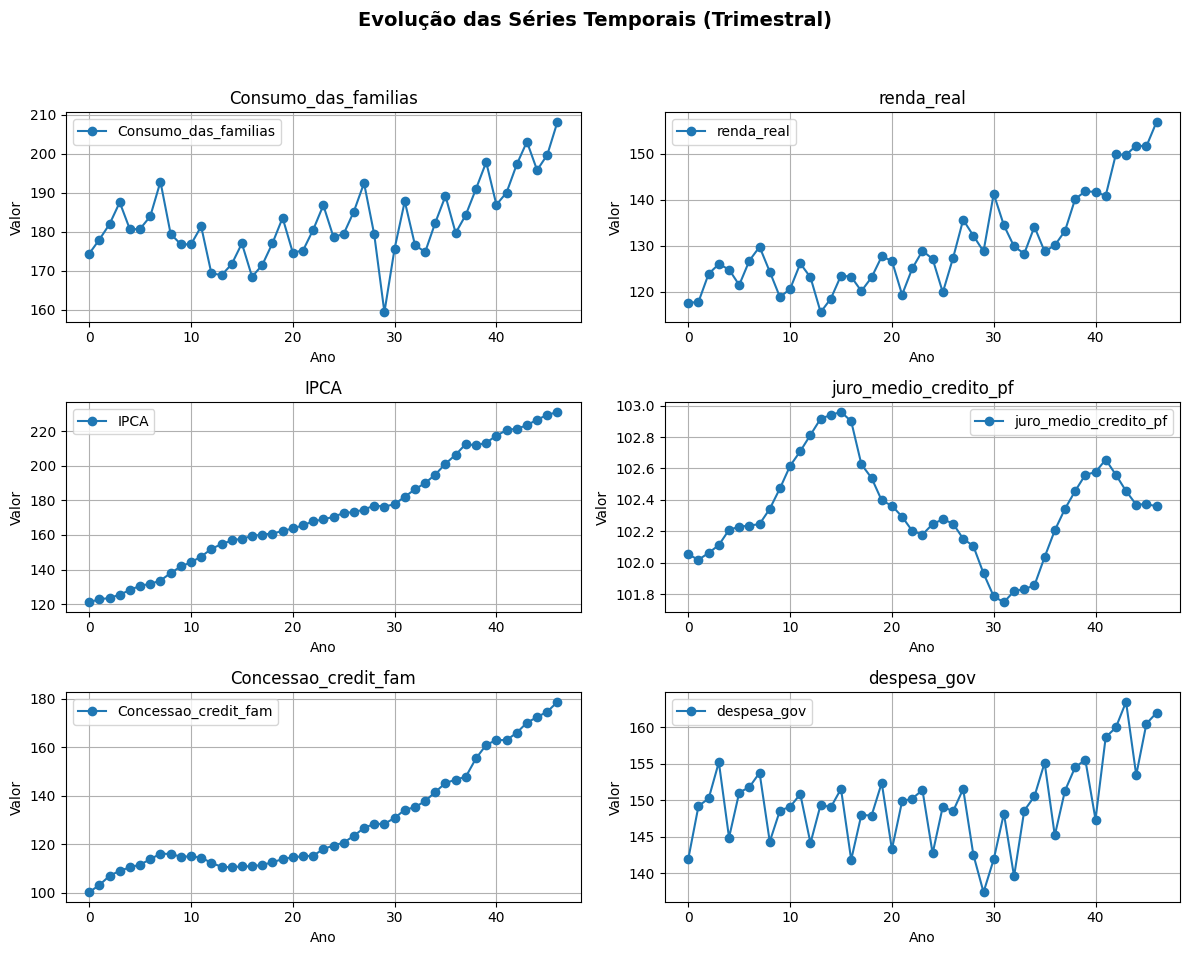

In [ ]:
# Criar gráficos
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
fig.suptitle("Evolução das Séries Temporais (Trimestral)", fontsize=14, fontweight="bold")

# Listar as variáveis para plotagem
variaveis = ['Consumo_das_familias','renda_real','IPCA', 'juro_medio_credito_pf','Concessao_credit_fam','despesa_gov']

# Iterar sobre cada variável e plotar
for ax, var in zip(axes.flatten(), variaveis):
    ax.plot(df.index, df[var], marker="o", linestyle="-", label=var)
    ax.set_title(var)
    ax.set_xlabel("Ano")
    ax.set_ylabel("Valor")
    ax.grid(True)
    ax.legend()

# Ajustar espaçamento
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

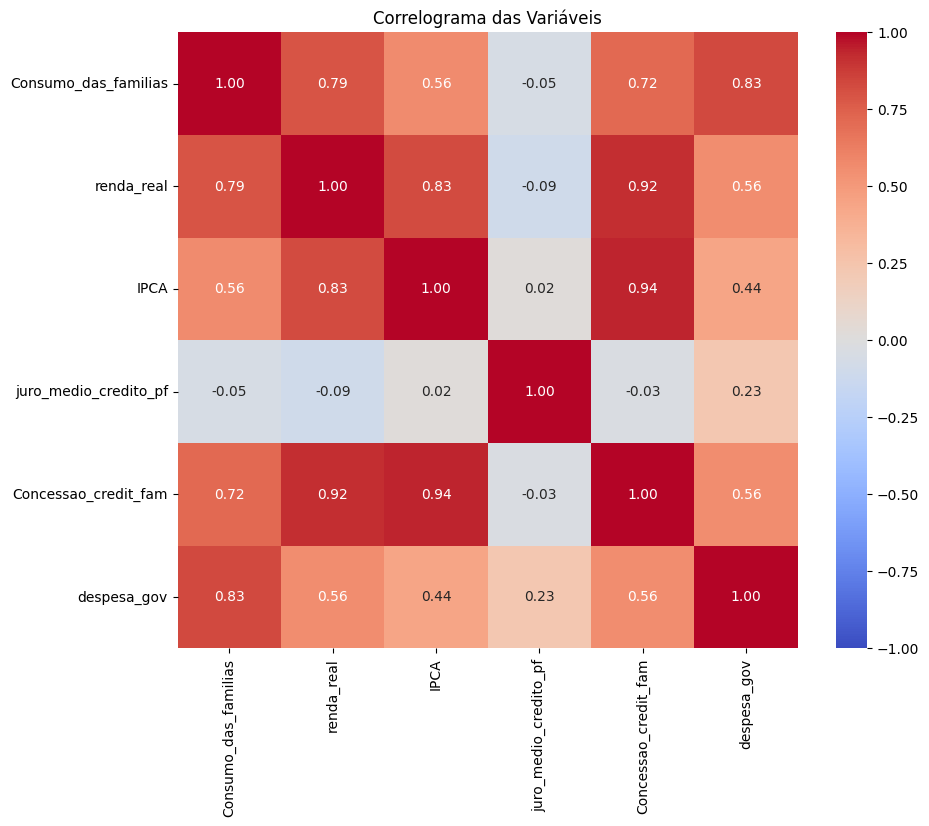

In [ ]:
import seaborn as sns

# Excluindo a coluna 'Data' para o correlograma
df_numeric = df.drop(columns=['data'])

# Calculando a matriz de correlação
corr = df_numeric.corr()

# Criando o correlograma
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlograma das Variáveis')
plt.show()

In [ ]:
df = df.drop('juro_medio_credito_pf', axis=1)  # axis=1 indica que estamos removendo uma coluna

In [ ]:
df = df.dropna()
df.tail()

,data,Consumo_das_familias,renda_real,IPCA,juro_medio_credito_pf,Concessao_credit_fam,despesa_gov
42,2023-09-30,197.26,149.922953,221.499939,102.560000,166.077042,159.96
43,2023-12-31,203.08,149.813497,223.418467,102.456667,170.226972,163.47
44,2024-03-31,195.80,151.831901,226.770701,102.370000,172.525299,153.45
45,2024-06-30,199.73,151.677880,229.363057,102.373333,174.766943,160.48
46,2024-09-30,208.18,156.989539,231.216965,102.360000,178.821736,161.98


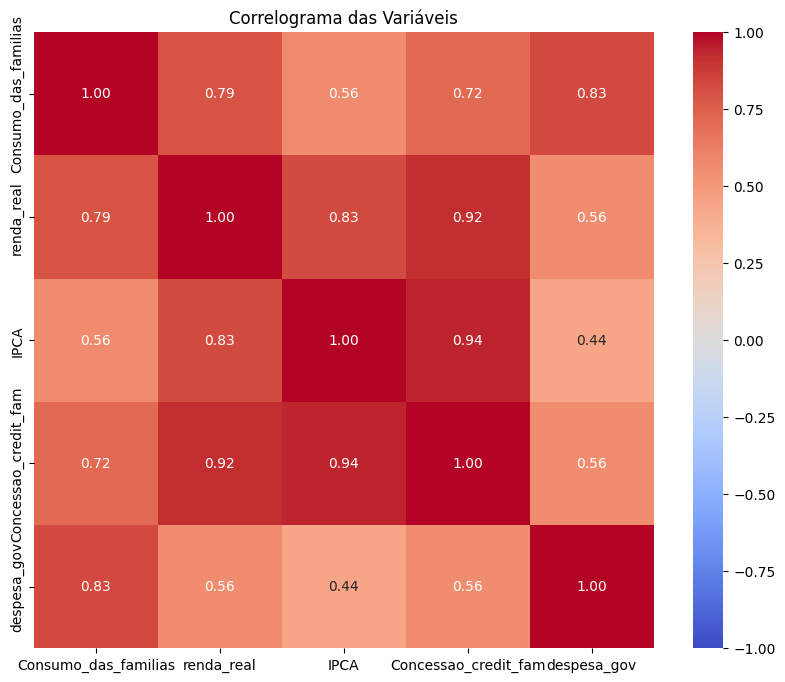

In [ ]:
# Excluindo a coluna 'Data' para o correlograma
df_numeric = df.drop(columns=['data'])

# Calculando a matriz de correlação
corr = df_numeric.corr()

# Criando o correlograma
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlograma das Variáveis')
plt.show()

In [ ]:
import statsmodels.api as sm
# Definir variáveis dependente e independentes
X = df[['IPCA','despesa_gov','juro_medio_credito_pf']]
y = df['Consumo_das_familias']

# Intercepto
X = sm.add_constant(X)

# Ajustar o modelo de regressão
modelo = sm.OLS(y, X).fit()

# Exibir os resultados
print(modelo.summary())

                             OLS Regression Results                             
Dep. Variable:     Consumo_das_familias   R-squared:                       0.787
Model:                              OLS   Adj. R-squared:                  0.773
Method:                   Least Squares   F-statistic:                     53.07
Date:                  Wed, 05 Mar 2025   Prob (F-statistic):           1.67e-14
Time:                          09:38:20   Log-Likelihood:                -136.73
No. Observations:                    47   AIC:                             281.5
Df Residuals:                        43   BIC:                             288.9
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const     

In [ ]:
import statsmodels.api as sm
# Definir variáveis dependente e independentes
X = df[['Concessao_credit_fam','despesa_gov']]
y = df['Consumo_das_familias']

# Intercepto
X = sm.add_constant(X)

# Ajustar o modelo de regressão
modelo = sm.OLS(y, X).fit()

# Exibir os resultados
print(modelo.summary())

                             OLS Regression Results                             
Dep. Variable:     Consumo_das_familias   R-squared:                       0.780
Model:                              OLS   Adj. R-squared:                  0.770
Method:                   Least Squares   F-statistic:                     77.93
Date:                  Tue, 04 Mar 2025   Prob (F-statistic):           3.47e-15
Time:                          02:31:46   Log-Likelihood:                -137.55
No. Observations:                    47   AIC:                             281.1
Df Residuals:                        44   BIC:                             286.6
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const       

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calcular VIF
vif_data = pd.DataFrame()
vif_data['Variável'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                Variável            VIF
0                  const  113578.331540
1                   IPCA       1.255224
2            despesa_gov       1.323285
3  juro_medio_credito_pf       1.063505


In [ ]:
''' Realização dos teste de estacionariedade, para na sequência verificar cointegração do modelo. Até esse momento, as opções são ARDL ou VAR'''


from statsmodels.tsa.stattools import adfuller, kpss

# Função para rodar os testes KPSS e ADF. Ambos são utilizados para melhorar a tomada de decisão dentro do modelo
''' Fiz dessa forma, pois julgo que restam menos dúvida em relação à estacionariedade'''
def stationarity_tests(series, name):
    result_adf = adfuller(series.dropna(), autolag='AIC')
    result_kpss = kpss(series.dropna(), nlags="auto")

    print(f"\n>>> Testes para {name}")
    print(f"ADF Test Statistic: {result_adf[0]:.4f}, p-value: {result_adf[1]:.4f} ({'Estacionária' if result_adf[1] < 0.05 else 'Não Estacionária'})")
    print(f"KPSS Test Statistic: {result_kpss[0]:.4f}, p-value: {result_kpss[1]:.4f} ({'Não Estacionária' if result_kpss[1] < 0.05 else 'Estacionária'})")

# Aplicar os testes às variáveis de interesse
for var in ['renda_real', 'IPCA', 'despesa_gov', 'Consumo_das_familias']:
    stationarity_tests(df[var], var)


>>> Testes para renda_real
ADF Test Statistic: 2.0768, p-value: 0.9988 (Não Estacionária)
KPSS Test Statistic: 0.8617, p-value: 0.0100 (Não Estacionária)

>>> Testes para IPCA
ADF Test Statistic: 0.3227, p-value: 0.9784 (Não Estacionária)
KPSS Test Statistic: 1.0201, p-value: 0.0100 (Não Estacionária)

>>> Testes para despesa_gov
ADF Test Statistic: -0.8678, p-value: 0.7984 (Não Estacionária)
KPSS Test Statistic: 0.4496, p-value: 0.0558 (Estacionária)

>>> Testes para Consumo_das_familias
ADF Test Statistic: -0.2659, p-value: 0.9302 (Não Estacionária)
KPSS Test Statistic: 0.6626, p-value: 0.0169 (Não Estacionária)


<ipython-input-9-6661cad7e592>:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result_kpss = kpss(series.dropna(), nlags="auto")
<ipython-input-9-6661cad7e592>:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result_kpss = kpss(series.dropna(), nlags="auto")


In [ ]:
# Passando variável do  DataFrame com os dados completos e teste
n_observacoes = len(df)
n_teste = 12  # Últimos 12 obs para teste


df_treino = df.iloc[:-n_teste]  # Todos os dados, exceto os últimos 12 obs
df_teste = df.iloc[-n_teste:]   # Últimos 12 obs

In [ ]:
#  variáveis dependente e independentes no conjunto de treino
X_treino = df_treino[['IPCA','despesa_gov','juro_medio_credito_pf']] #'renda_real',
y_treino = df_treino['Consumo_das_familias']

# Ajustar o modelo de regressão
modelo_treino = sm.OLS(y_treino, X_treino).fit()

In [ ]:

# Variáveis independentes no conjunto de teste
X_teste = df_teste[['IPCA','despesa_gov','juro_medio_credito_pf']]

# Variável para realizar previsão
y_pred_teste = modelo_treino.predict(X_teste)

# Adicionar as previsões ao DataFrame de teste
df_teste['Consumo_das_familias_predito'] = y_pred_teste

<ipython-input-12-1bc2ea2a2638>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_teste['Consumo_das_familias_predito'] = y_pred_teste


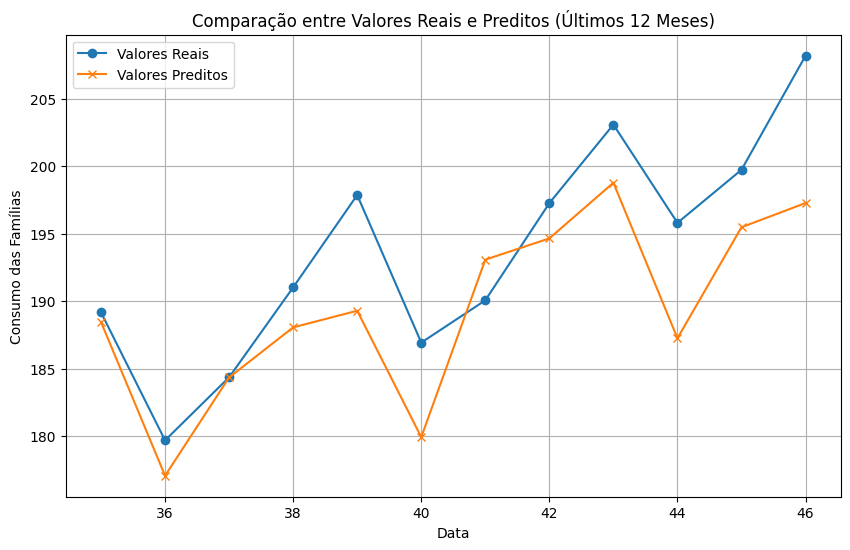

In [ ]:
# Gráfico dos valores reais vs preditos
plt.figure(figsize=(10, 6))
plt.plot(df_teste.index, df_teste['Consumo_das_familias'], label='Valores Reais', marker='o')
plt.plot(df_teste.index, df_teste['Consumo_das_familias_predito'], label='Valores Preditos', marker='x')
plt.title('Comparação entre Valores Reais e Preditos (Últimos 12 Meses)')
plt.xlabel('Data')
plt.ylabel('Consumo das Famílias')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calcular RMSE e MAE para testar se tem ou não overfiting
rmse = np.sqrt(mean_squared_error(df_teste['Consumo_das_familias'], df_teste['Consumo_das_familias_predito']))
mae = mean_absolute_error(df_teste['Consumo_das_familias'], df_teste['Consumo_das_familias_predito'])

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

RMSE: 5.652128687988799
MAE: 4.627384479720365


In [ ]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Selecionar as variáveis para o teste de cointegração
df_coint = df[['IPCA','despesa_gov','juro_medio_credito_pf']]

# Aplicar o teste de Johansen
johansen_test = coint_johansen(df_coint, det_order=0, k_ar_diff=1)

# Exibir os resultados
print("Valores críticos:")
print(johansen_test.cvt)  # Valores críticos em 90%, 95% e 99%

print("\nEstatísticas do teste:")
print(johansen_test.lr1)  # Estatística do traço (trace test)

print("\nNúmero de cointegrações:")
for i, stat in enumerate(johansen_test.lr1):
    if stat > johansen_test.cvt[i, 1]:  # Comparando com o valor crítico de 5%
        print(f"Ranque {i}: Existe cointegração ao nível de 5%.")
    else:
        print(f"Ranque {i}: Não existe cointegração ao nível de 5%.")

Valores críticos:
[[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]

Estatísticas do teste:
[23.34547911  8.45997835  2.19397359]

Número de cointegrações:
Ranque 0: Não existe cointegração ao nível de 5%.
Ranque 1: Não existe cointegração ao nível de 5%.
Ranque 2: Não existe cointegração ao nível de 5%.


In [ ]:
df.head()

,data,Consumo_das_familias,renda_real,IPCA,Concessao_credit_fam,despesa_gov
0,2013-03-31,174.38,117.588766,121.080067,100.245178,141.99
1,2013-06-30,178.01,117.823885,122.778111,103.203116,149.21
2,2013-09-30,181.96,123.942617,123.519873,106.997914,150.24
3,2013-12-31,187.56,126.037851,125.445582,109.089408,155.21
4,2014-03-31,180.61,124.861605,128.110954,110.498244,144.88


In [ ]:
df.tail()

,data,Consumo_das_familias,renda_real,IPCA,juro_medio_credito_pf,Concessao_credit_fam,despesa_gov
42,2023-09-30,197.26,149.922953,221.499939,102.560000,166.077042,159.96
43,2023-12-31,203.08,149.813497,223.418467,102.456667,170.226972,163.47
44,2024-03-31,195.80,151.831901,226.770701,102.370000,172.525299,153.45
45,2024-06-30,199.73,151.677880,229.363057,102.373333,174.766943,160.48
46,2024-09-30,208.18,156.989539,231.216965,102.360000,178.821736,161.98


In [ ]:
df['despesa_gov_lag1'] = df['despesa_gov'].shift(1)
df['IPCA_lag1'] = df['IPCA'].shift(1)
df['IPCA_lag1'] = df['IPCA'].shift(1)
df['renda_real_lag1'] = df['renda_real'].shift(1)
df['Concessao_credit_fam_lag1'] = df['Concessao_credit_fam'].shift(1)
df['Consumo_das_familias_lag1'] = df['Consumo_das_familias'].shift(1)

df['juro_medio_credito_pf_lag1'] = df['juro_medio_credito_pf'].shift(1)
df['juro_medio_credito_pf_lag2'] = df['juro_medio_credito_pf'].shift(2)
df.head()


df.dropna(inplace=True)

In [ ]:

df.head()

,data,Consumo_das_familias,renda_real,IPCA,juro_medio_credito_pf,Concessao_credit_fam,despesa_gov,despesa_gov_lag1,IPCA_lag1,renda_real_lag1,Concessao_credit_fam_lag1,Consumo_das_familias_lag1,juro_medio_credito_pf_lag1,juro_medio_credito_pf_lag2
2,2013-09-30,181.96,123.942617,123.519873,102.063333,106.997914,150.24,149.21,122.778111,117.823885,103.203116,178.01,102.020000,102.053333
3,2013-12-31,187.56,126.037851,125.445582,102.113333,109.089408,155.21,150.24,123.519873,123.942617,106.997914,181.96,102.063333,102.020000
4,2014-03-31,180.61,124.861605,128.110954,102.210000,110.498244,144.88,155.21,125.445582,126.037851,109.089408,187.56,102.113333,102.063333
5,2014-06-30,180.74,121.488049,130.627090,102.230000,111.636694,151.05,144.88,128.110954,124.861605,110.498244,180.61,102.210000,102.113333
6,2014-09-30,183.97,126.798550,131.656719,102.236667,113.825669,151.80,151.05,130.627090,121.488049,111.636694,180.74,102.230000,102.210000


In [ ]:
df.dropna

<bound method DataFrame.dropna of          data  Consumo_das_familias  renda_real        IPCA  \
2  2013-09-30                181.96  123.942617  123.519873   
3  2013-12-31                187.56  126.037851  125.445582   
4  2014-03-31                180.61  124.861605  128.110954   
5  2014-06-30                180.74  121.488049  130.627090   
6  2014-09-30                183.97  126.798550  131.656719   
7  2014-12-31                192.84  129.795700  133.619875   
8  2015-03-31                179.47  124.392091  137.922426   
9  2015-06-30                176.80  118.866510  141.748658   
10 2015-09-30                176.77  120.625127  144.197632   
11 2015-12-31                181.37  126.174798  147.463925   
12 2016-03-31                169.39  123.158911  151.912950   
13 2016-06-30                168.88  115.572894  154.713640   
14 2016-09-30                171.70  118.522079  156.783614   
15 2016-12-31                177.02  123.547617  157.852017   
16 2017-03-31                168.47  123.278569  159.345813   
17 2017-06-30                171.49  120.171818  160.217480   
18 2017-09-30                177.05  123.141621  160.810117   
19 2017-12-31                183.58  127.695112  162.299826   
20 2018-03-31                174.67  126.754059  163.797048   
21 2018-06-30                175.19  119.368652  165.562474   
22 2018-09-30                180.50  125.088188  167.887840   
23 2018-12-31                186.80  128.932778  168.978887   
24 2019-03-31                178.63  127.160416  170.481853   
25 2019-06-30                179.46  119.877159  172.709568   
26 2019-09-30                185.20  127.317693  173.228194   
27 2019-12-31                192.49  135.682857  174.676701   
28 2020-03-31                179.32  132.215759  177.013886   
29 2020-06-30                159.39  128.805380  176.399268   
30 2020-09-30                175.67  141.311601  177.778072   
31 2020-12-31                187.82  134.479194  182.101500   
32 2021-03-31                176.64  129.876436  186.369918   
33 2021-06-30                174.79  128.320673  190.017531   
34 2021-09-30                182.35  134.172454  194.919677   
35 2021-12-31                189.17  128.791345  201.200737   
36 2022-03-31                179.69  130.112351  206.392739   
37 2022-06-30                184.36  133.253321  212.659882   
38 2022-09-30                191.02  140.195329  211.771204   
39 2022-12-31                197.86  141.887172  213.373586   
40 2023-03-31                186.93  141.741398  217.404618   
41 2023-06-30                190.06  140.915661  220.653126   
42 2023-09-30                197.26  149.922953  221.499939   
43 2023-12-31                203.08  149.813497  223.418467   
44 2024-03-31                195.80  151.831901  226.770701   
45 2024-06-30                199.73  151.677880  229.363057   
46 2024-09-30                208.18  156.989539  231.216965   

    juro_medio_credito_pf  Concessao_credit_fam  despesa_gov  \
2              102.063333            106.997914       150.24   
3              102.113333            109.089408       155.21   
4              102.210000            110.498244       144.88   
5              102.230000            111.636694       151.05   
6              102.236667            113.825669       151.80   
7              102.246667            116.196710       153.76   
8              102.343333            116.001841       144.33   
9              102.473333            114.920022       148.59   
10             102.616667            114.998121       149.10   
11             102.710000            114.561029       150.84   
12             102.813333            112.323274       144.13   
13             102.916667            110.755443       149.39   
14             102.940000            110.525272       149.04   
15             102.960000            110.926647       151.55   
16             102.900000            110.912547       141.85   
17             102.626667            111.54

In [ ]:
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt

# Selecionar as variáveis para o modelo VAR
var_data = df[['IPCA','despesa_gov_lag1','IPCA_lag1','Consumo_das_familias']]
# Passo 2: Ajustar o modelo VAR
modelo_var = VAR(var_data)

# Selecionar o número ótimo de defasagens (reduzindo maxlags para 5)
resultado_selecao = modelo_var.select_order(maxlags=4)  # Testar até 5 defasagens
print(resultado_selecao.summary())

# Ajustar o modelo com o número ótimo de defasagens
lag_order = resultado_selecao.aic  # Usar o critério AIC para selecionar o número de defasagens
modelo_var_ajustado = modelo_var.fit(lag_order)
print(modelo_var_ajustado.summary())

# Passo 3: Fazer previsões
forecast_steps = 9
previsoes = modelo_var_ajustado.forecast(var_data.values[-lag_order:], steps=forecast_steps)

# Criar um DataFrame com as previsões
previsoes_df = pd.DataFrame(previsoes, columns=var_data.columns)

# Ajustar o índice para os próximos trimestres
previsoes_df.index = pd.date_range(start=df.index[-1], periods=forecast_steps, freq='QE')

print(previsoes_df)

# Passo 4: Visualizar o histórico e as previsões de Consumo_das_familias
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Consumo_das_familias'], label='Histórico', marker='o')
plt.plot(previsoes_df.index, previsoes_df['Consumo_das_familias'], label='Previsões', linestyle='--', marker='o', color='red')
plt.title('Projeção do Consumo das Famílias (Trimestral)')
plt.xlabel('Data')
plt.ylabel('Consumo das Famílias')
plt.legend()
plt.grid()
plt.show()


 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       14.90       15.07   2.955e+06       14.96
1      -53.66      -52.82   5.003e-24      -53.35
2     -55.17*     -53.67*  1.125e-24*     -54.63*
3      -51.13      -48.95   6.847e-23      -50.33
4      -50.22      -47.38   1.906e-22      -49.19
-------------------------------------------------


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


LinAlgError: Singular matrix

Autovalores do modelo VAR:
[ 1.98445966e+00+0.53383069j  1.98445966e+00-0.53383069j
 -1.14384244e+00+1.34896858j -1.14384244e+00-1.34896858j
 -2.88138188e-01-1.11786062j -2.88138188e-01+1.11786062j
  9.76228528e-01+0.60713702j  9.76228528e-01-0.60713702j
 -5.69344784e-01-0.95888719j -5.69344784e-01+0.95888719j
 -1.10675088e+00-0.j          7.39421657e-01+0.80247531j
  7.39421657e-01-0.80247531j -9.95781077e-01+0.42527719j
 -9.95781077e-01-0.42527719j  2.51628872e-01-1.01924774j
  2.51628872e-01+1.01924774j  1.00323548e+00+0.28474626j
  1.00323548e+00-0.28474626j  1.22629672e-03-1.02670456j
  1.22629672e-03+1.02670456j -1.01122175e+00-0.j
  1.00908686e+00-0.05417848j  1.00908686e+00+0.05417848j]
O modelo VAR NÃO é estável.


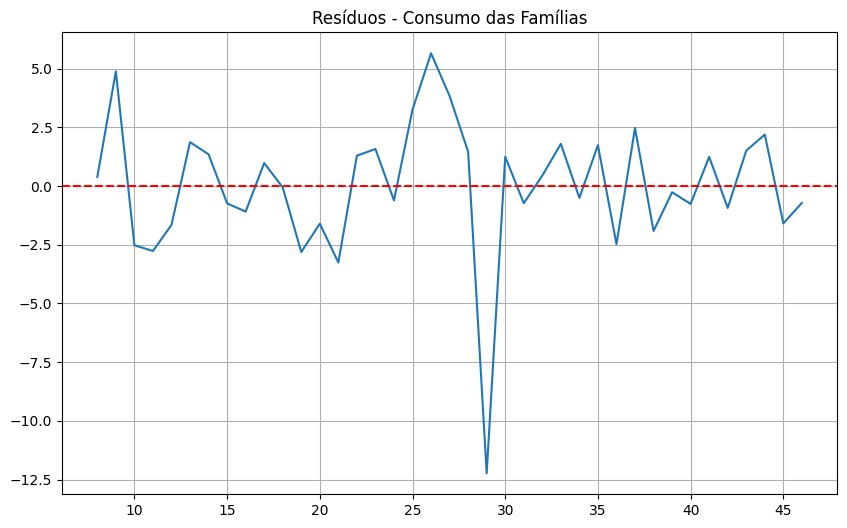

In [ ]:
# Passo 5: Verificar estabilidade
autovalores = modelo_var_ajustado.roots
print("Autovalores do modelo VAR:")
print(autovalores)
if all(np.abs(autovalores) < 1):
    print("O modelo VAR é estável.")
else:
    print("O modelo VAR NÃO é estável.")

# Passo 6: Análise dos resíduos
residuos = modelo_var_ajustado.resid
plt.figure(figsize=(10, 6))
plt.plot(residuos['Consumo_das_familias'])
plt.title('Resíduos - Consumo das Famílias')
plt.axhline(0, color='red', linestyle='--')
plt.grid()
plt.show()

In [ ]:
previsoes_df['Consumo_das_familias']

,Consumo_das_familias
1970-03-31 00:00:00.000000046,215.530536
1970-06-30 00:00:00.000000046,207.258420
1970-09-30 00:00:00.000000046,208.103278
1970-12-31 00:00:00.000000046,213.966106
1971-03-31 00:00:00.000000046,221.666302
1971-06-30 00:00:00.000000046,215.104864
1971-09-30 00:00:00.000000046,215.884442
1971-12-31 00:00:00.000000046,221.031324
1972-03-31 00:00:00.000000046,227.482490


In [ ]:
previsoes_df.to_excel('previsoes_05-03(11).xlsx')